# Interactive Notebook 02 - PWM extensions:

This interactive Jupyter notebook introduces extensions to pulse width modulation, harmonic analysis, and 6-step operation within a three-phase voltage-source inverter.

For help with the installation of the required software, consider the comments in ```CTPD_course\interactive_notebooks\README.md```.
Throughout the exercises, we will be using a combination of scientific computation libraries from the [JAX](https://docs.jax.dev/en/latest/notebooks/thinking_in_jax.html) ecosystem and visualize them with [matplotlib](https://matplotlib.org/) and [ipywidgets](https://ipywidgets.readthedocs.io/en/stable/).

### Preliminaries & Imports:

In [1]:
# automatically reloads imported ```.py```-files once they are changed and saved
%load_ext autoreload
%autoreload 2

In [2]:
%%html
<style>
div.jupyter-widgets.widget-label {display: none;}
</style>

In [3]:
# imports required packages
from functools import partial
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc
mpl.rcParams.update({'font.size': 20})
import jax
import jax.numpy as jnp

In [4]:
from analytical_harmonics import build_analytical_spectrum, visualize_analytical_spectrum
from helper_functions import triangular_signal, compute_three_phase_signals, three_phase_plot, plot_fft_spectrum, get_fft_spectrum

(**Optional**: If you have LaTeX installed, you can use the following lines for pretty rendering of plot labels.
Any LaTeX installation should work, as long as all the required packages are installed, e.g., [MiKTeX](https://miktex.org/) or [TeXLive](https://www.tug.org/texlive/).

If you do not have LaTeX installed, you can comment the next cell out or skip it.)

In [5]:
rc('font',**{'family':'serif','serif':['Helvetica']})
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble']=r"\usepackage{bm}\usepackage{amsmath}\usepackage{upgreek}"

---

### Three-phase harmonics:

In [6]:
T_full = 0.2  # s
N = 10_000
f_sampling = N / T_full  # 'N' samples per 'T_full' seconds
t = jnp.linspace(0, T_full, N)
print(t.shape)


# pulse / carrier frequency
f_p = 1000  # Hz
T_p = 1 / f_p

(10000,)


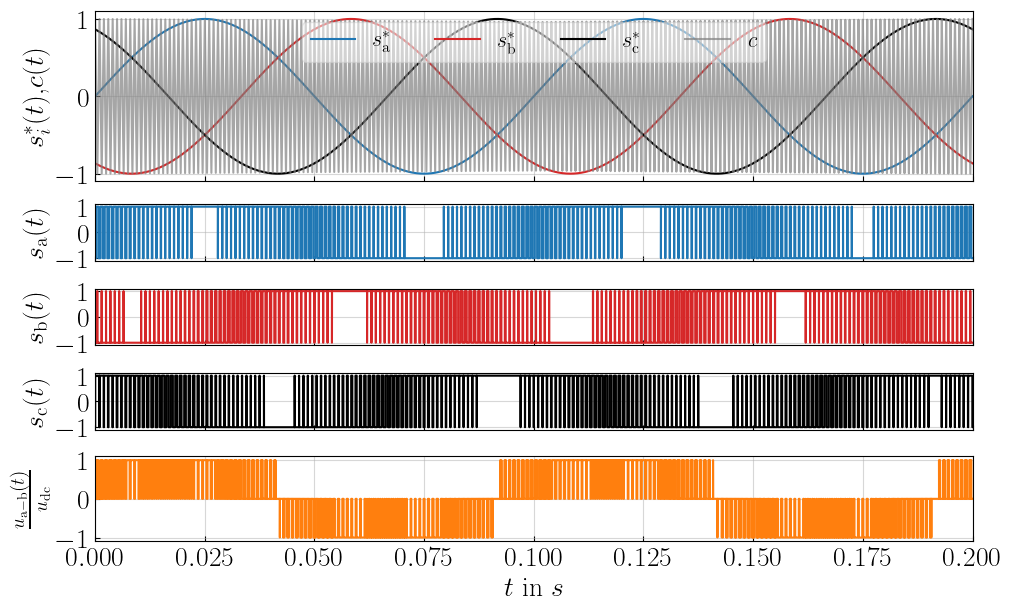

In [7]:
c_t = triangular_signal(t, frequency=f_p, amplitude=1.0, phase=0.0)

u_dc = 20  # V
m = 1.0
f_fundamental = 10  # Hz
u_ref_t, s_ref_t, s_t = compute_three_phase_signals(m=m, u_ref_freq=f_fundamental, t=t, c_t=c_t, u_dc=u_dc)
fig, axs = three_phase_plot(t, s_ref_t, c_t, s_t)

#### FFT-based harmonics:

We utilize the fast fourier transform (FFT) to compute the spectrum of our signals.

First we consider the spectrum of our reference wave for a sanity check.

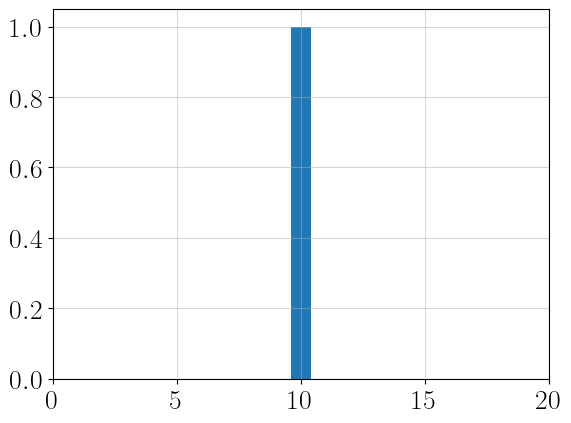

In [8]:
# test FFT settings on single sine wave:
spectrum = jnp.abs(jnp.fft.rfft(s_ref_t[..., 0], axis=0))
freqs = jnp.fft.rfftfreq(N, d=1/f_sampling)
amps  = (2 / N) * jnp.abs(spectrum)

plt.bar(freqs[:150], amps[:150])
plt.grid(alpha=0.5)
plt.xlim(0, 20)
plt.show()

As expected, the only contribution is at the fundamental frequency $f_1 = 10 \, \mathrm{Hz}$.

Next we consider the spectrum of the resulting switching signal $s_\mathrm{a}(t)$:

(<Figure size 1000x800 with 4 Axes>,
 array([<Axes: ylabel='$\\hat{s}$'>, <Axes: ylabel='$\\hat{s}$'>,
        <Axes: ylabel='$\\hat{s}$'>,
        <Axes: xlabel='$f / f_1$', ylabel='$\\hat{s}$'>], dtype=object))

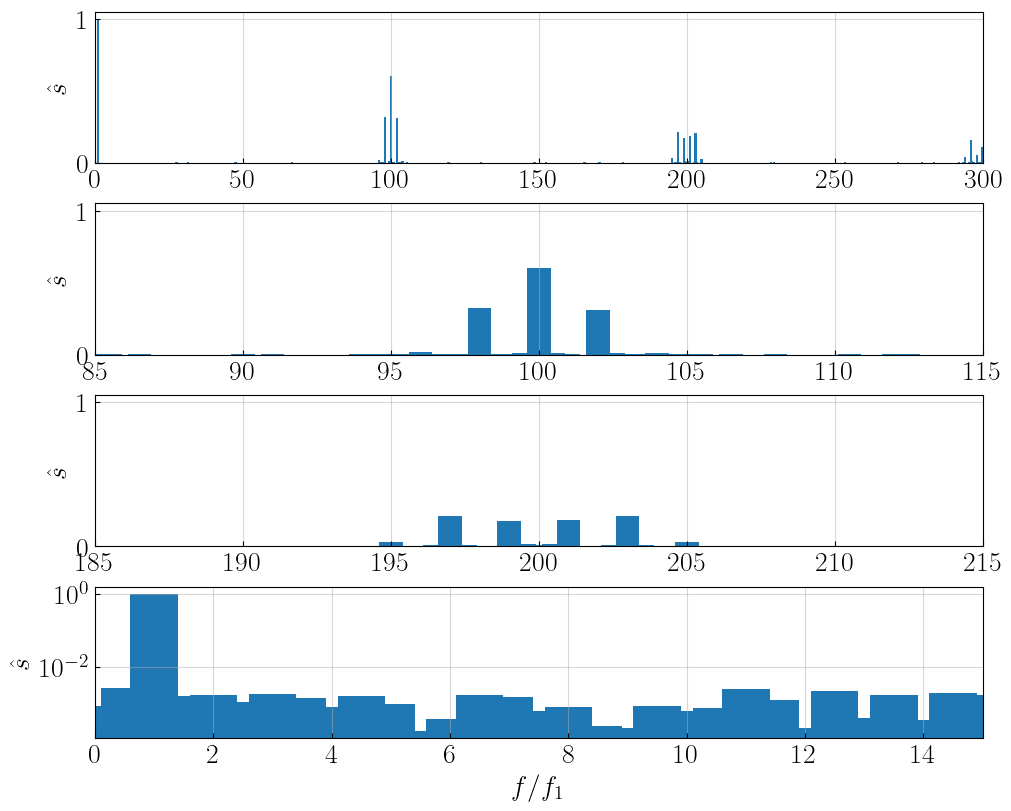

In [9]:
plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_fundamental)

and the spectrum of the normalized line-to-line voltage:

$$\frac{u_\mathrm{a-b}(t)}{u_\mathrm{dc} / 2}$$

(<Figure size 1000x800 with 4 Axes>,
 array([<Axes: ylabel='$\\hat{s}$'>, <Axes: ylabel='$\\hat{s}$'>,
        <Axes: ylabel='$\\hat{s}$'>,
        <Axes: xlabel='$f / f_1$', ylabel='$\\hat{s}$'>], dtype=object))

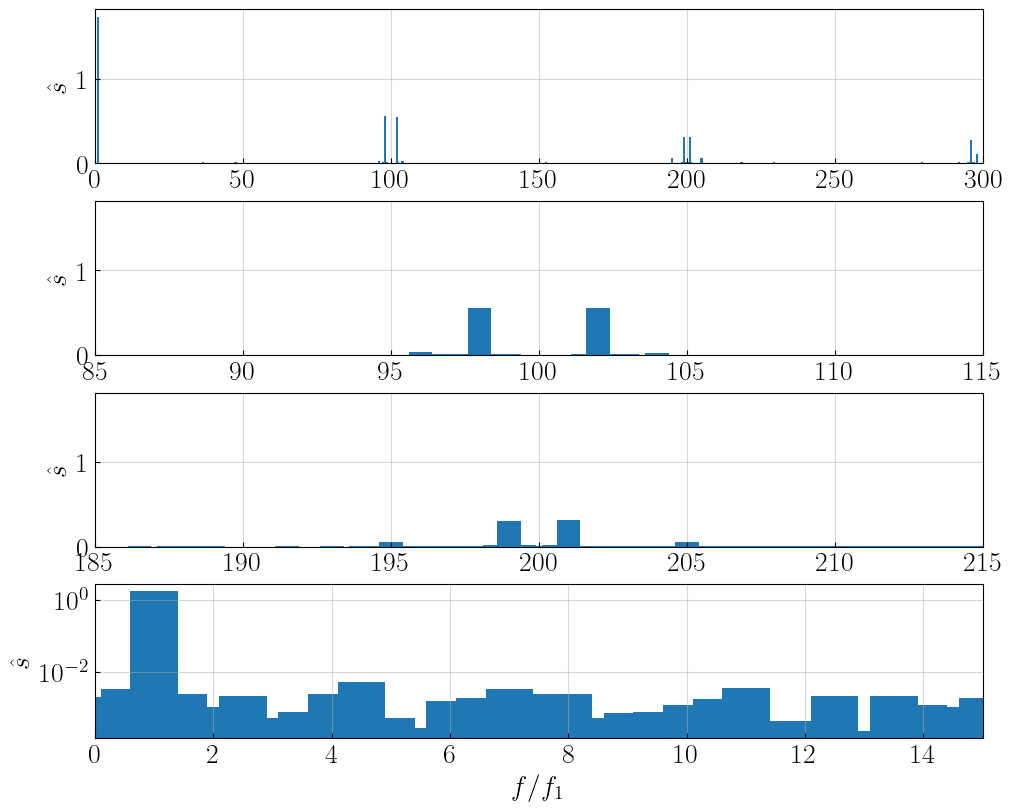

In [10]:
# exemplary line-to-line PWM harmonics:
plot_fft_spectrum(s_t[..., 0] - s_t[..., 1], f_sampling, N, f_fundamental)

#### Comparison of analytical and numerical spectra:

In order to ensure compliance between the FFT and the analytical derivation of the harmonic spectrum for the lecture, the two are compared in the following.

The analytical harmonic frequencies are given as

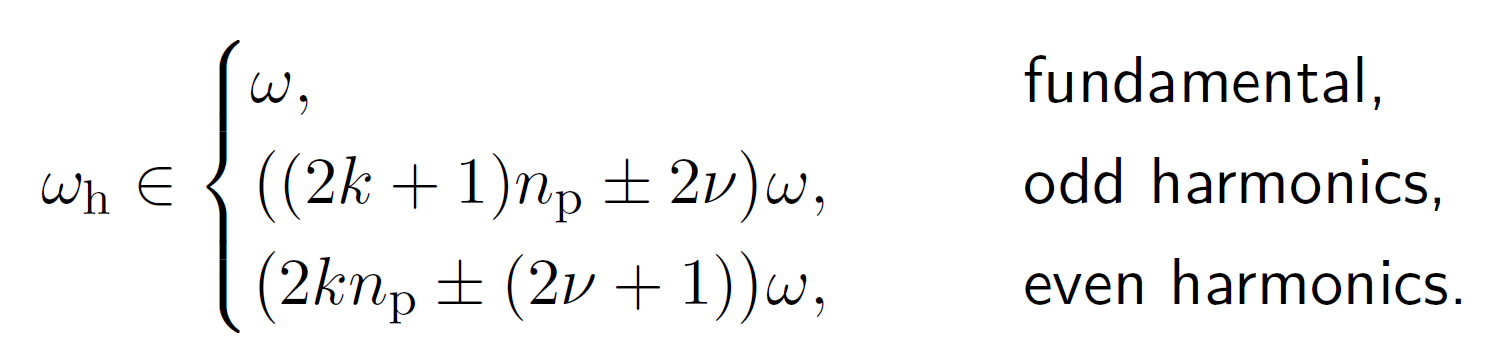

The following plot shows the fundamental frequency at $f/f_1 = 1$, the first odd harmonics at $f/f_1 = 100$ including the sidebands with +- even multiples of $f_1$, and the first even harmonics at $f/f_1 = 200$ including sidebands at +- odd multiples of $f_1$. Note that there is no harmonic content at exactly $f/f_1 = 200$.

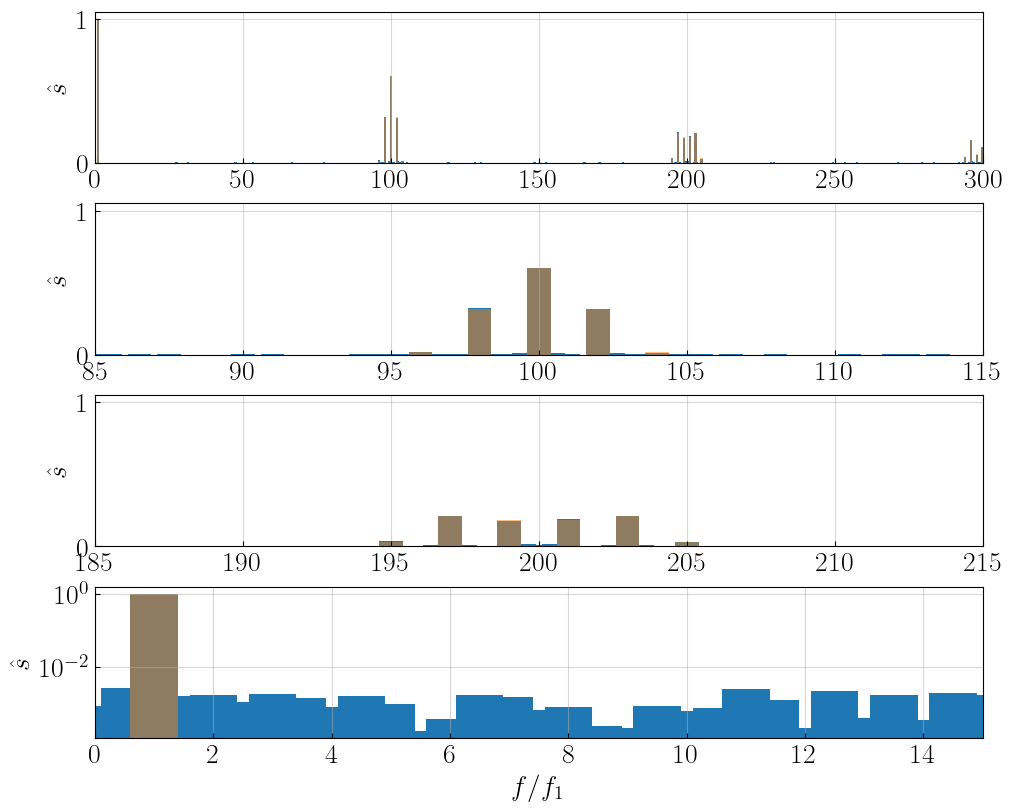

In [11]:
fig, axs = plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_fundamental)

## 

spectrum = build_analytical_spectrum(
    pulse_number=f_p/f_fundamental,  # 100
    modulation_index=m,
    fundamental_frequency_hz=f_fundamental,  # 10
)

frequencies = []
amplitudes = []
for freq_dict in spectrum:
    frequencies.append(freq_dict["normalized_frequency"])
    amplitudes.append(freq_dict["amplitude"])

for ax in axs:
    ax.bar(frequencies, amplitudes, alpha=0.5)

The FFT-based spectrum fits to the spectrum based on analytical calculations. We will consider only FFT-based spectra in the following.

#### Total harmonic distortion (THD):

The THD measures the ratio of the harmonic contribution of the fundamental frequency $f_1$ compared to all other harmonic content:

$$\mathrm{THD} = \sqrt{\frac{\sum^{\infty}_{n=2} {U^{(n)}}^2}{{U^{(1)}}^2}},$$

where $U^{(1)}$  is the amplitude of the fundamental frequency and $U^{(n)}$  is the amplitude of the $n$-th harmonic.

In [12]:
def get_amplitude_at_freq(amps, freqs, target_freq):
    idx = jnp.argmin(jnp.abs(freqs - target_freq))
    return amps[idx]

def compute_THD(amps, freqs, f_fundamental, max_n=300):
    amp_fundamental = get_amplitude_at_freq(amps, freqs, f_fundamental)      
    
    return jnp.sqrt((jnp.sum(amps**2) - amp_fundamental**2) / amp_fundamental**2)

In [13]:
u_ref_t, s_ref_t, s_t = compute_three_phase_signals(m=1, u_ref_freq=f_fundamental, t=t, c_t=c_t, u_dc=u_dc)

amps, freqs = get_fft_spectrum(s_t[..., 0], f_sampling, N)
compute_THD(amps, freqs, f_fundamental)

Array(1.0010962, dtype=float32)

#### Effective value (RMS):

The effective value is computed as the root mean square of the signal:

$$x_\mathrm{eff} = \sqrt{\frac{1}{T} \int_{t_0}^{t_0+T} x(t)^2}$$



In [14]:
@jax.jit
def get_effective_value(x_t):
    return jnp.sqrt(jnp.mean(x_t**2))

The effective value of the switching signals is always $1$, as they are only alternating between $-1$ and $1$.
However, we can consider the effective value of our line-to-line voltages to measure the effective output of our PWM strategy.
This can be done for the voltages but we are considering normalized line-to-line voltages:

$$\frac{u_\mathrm{a-b}(t)}{u_\mathrm{dc} / 2}$$

In [15]:
u_ref_t, s_ref_t, s_t = compute_three_phase_signals(m=1.0, u_ref_freq=f_fundamental, t=t, c_t=c_t, u_dc=u_dc)
get_effective_value(s_t[..., 0] - s_t[..., 1])

Array(1.4849916, dtype=float32)

### Zero sequence injection:

Allow the extension of the modulation index $m$ from $1$ to $2 / \sqrt{3} \approx 1.155$

with min-max zero-sequence injection:

$$s_0 (t) = \frac{1}{2} (\mathrm{max} \{s^*_{\mathrm{a}}, s^*_{\mathrm{b}}, s^*_{\mathrm{c}}\} + \mathrm{min} \{s^*_{\mathrm{a}}, s^*_{\mathrm{b}}, s^*_{\mathrm{c}}\})$$

In [16]:
def compute_three_phase_signals_zsi_minmax(m, u_ref_freq, t, c_t, u_dc):

    omega = u_ref_freq * 2 * jnp.pi
    s_ref_t = jnp.array(
        [
            m * jnp.sin(omega * t),
            m * jnp.sin(omega * t - jnp.pi * 2 / 3),
            m * jnp.sin(omega * t + jnp.pi * 2 / 3),
        ]
    ).T
    
    s_0_t = 0.5 * (jnp.max(s_ref_t, axis=-1) + jnp.min(s_ref_t, axis=-1))
    s_ref_t = s_ref_t - s_0_t[..., None]
    u_ref_t = u_dc / 2  * s_ref_t
    
    s_t = jnp.where(s_ref_t > c_t[..., None], 1, -1)

    return u_ref_t, s_ref_t, s_t, s_0_t

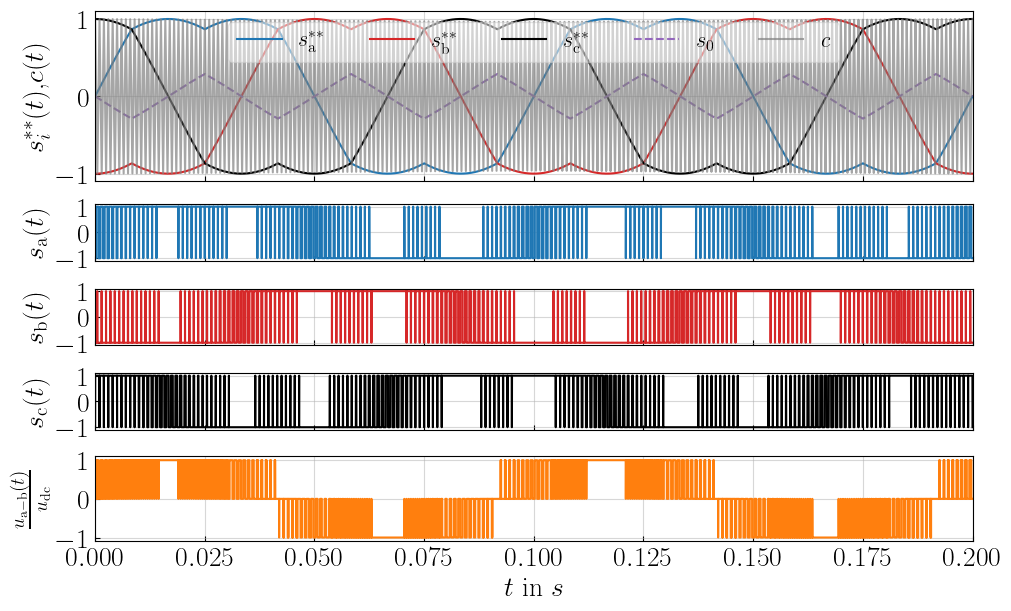

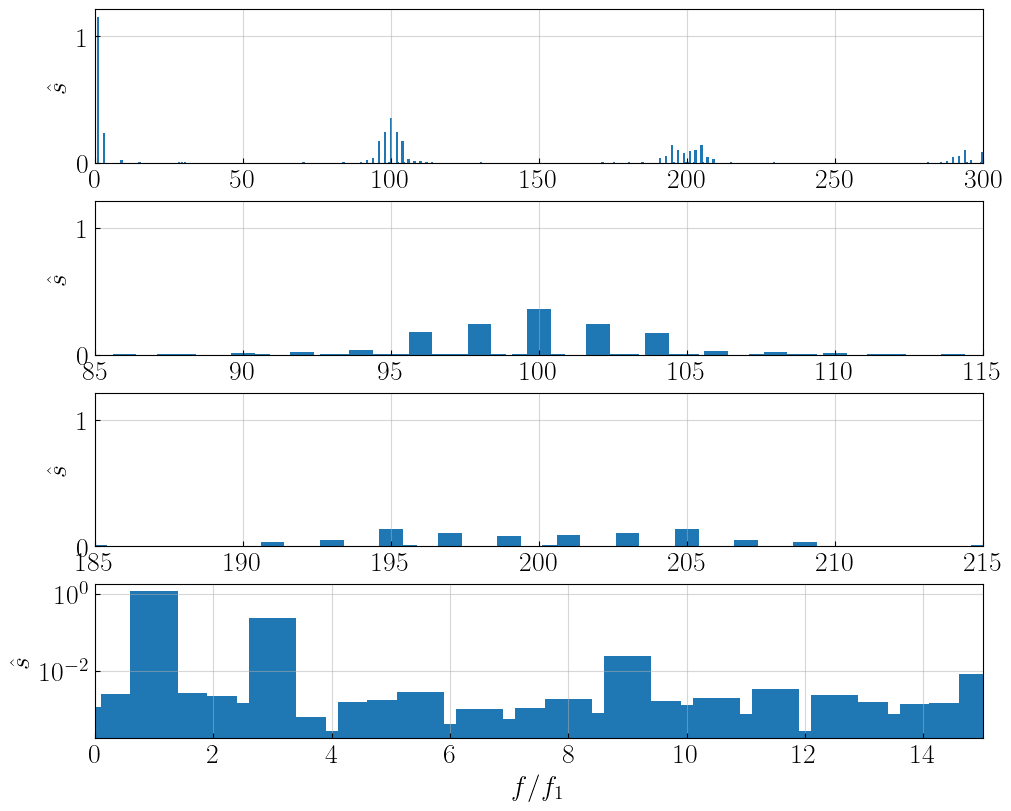

In [17]:
u_ref_t, s_ref_t, s_t, s_0_t = compute_three_phase_signals_zsi_minmax(
    m=2/jnp.sqrt(3),
    u_ref_freq=f_fundamental,
    t=t,
    c_t=c_t,
    u_dc=u_dc
)
fig, axs = three_phase_plot(t, s_ref_t, c_t, s_t, s_0_t)
plt.show()
plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_fundamental)
plt.show()

### Clipping for overmodulation operation:

In practice, the $u_{\mathrm{a},i}$, $u_{\mathrm{b},i}$, $u_{\mathrm{c},i}$ voltages cannot exceed $u_\mathrm{dc} / 2$ and are clipped.
But this has no effect on the switching pattern compared to zero-sequence injection without clipping.

In [18]:
def compute_three_phase_signals_zsi_clipping(m, u_ref_freq, t, c_t, u_dc):

    omega = u_ref_freq * 2 * jnp.pi
    s_ref_t = jnp.array(
        [
            m * jnp.sin(omega * t),
            m * jnp.sin(omega * t - jnp.pi * 2 / 3),
            m * jnp.sin(omega * t + jnp.pi * 2 / 3),
        ]
    ).T
    
    s_0_t = 1/2 * (jnp.max(s_ref_t, axis=-1) + jnp.min(s_ref_t, axis=-1))
    s_ref_t = jnp.clip(s_ref_t - s_0_t[..., None], min=-1, max=1)
    u_ref_t = u_dc / 2  * s_ref_t
    
    s_t = jnp.where(s_ref_t > c_t[..., None], 1, -1)

    return u_ref_t, s_ref_t, s_t, s_0_t

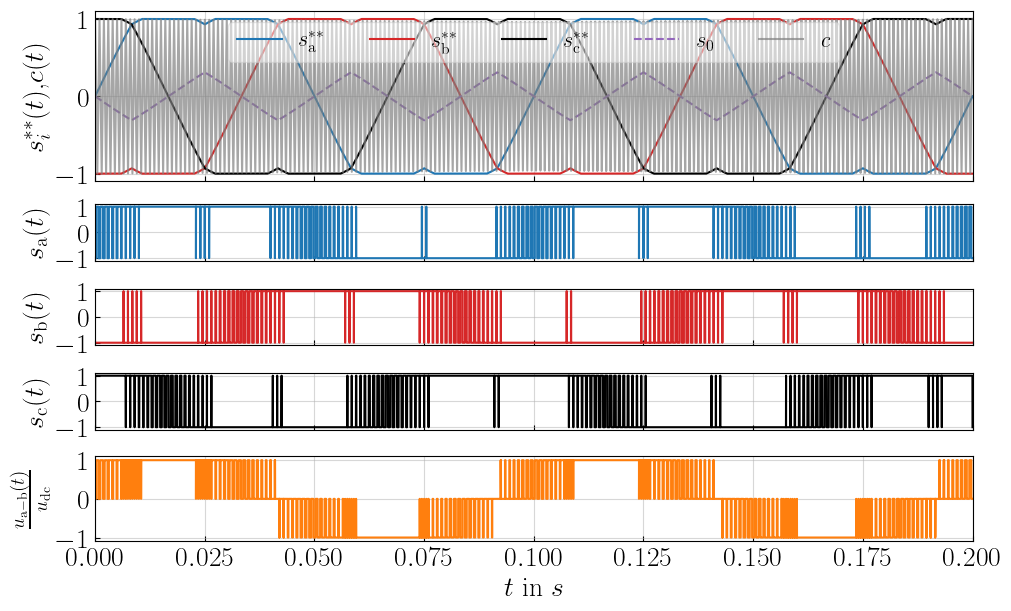

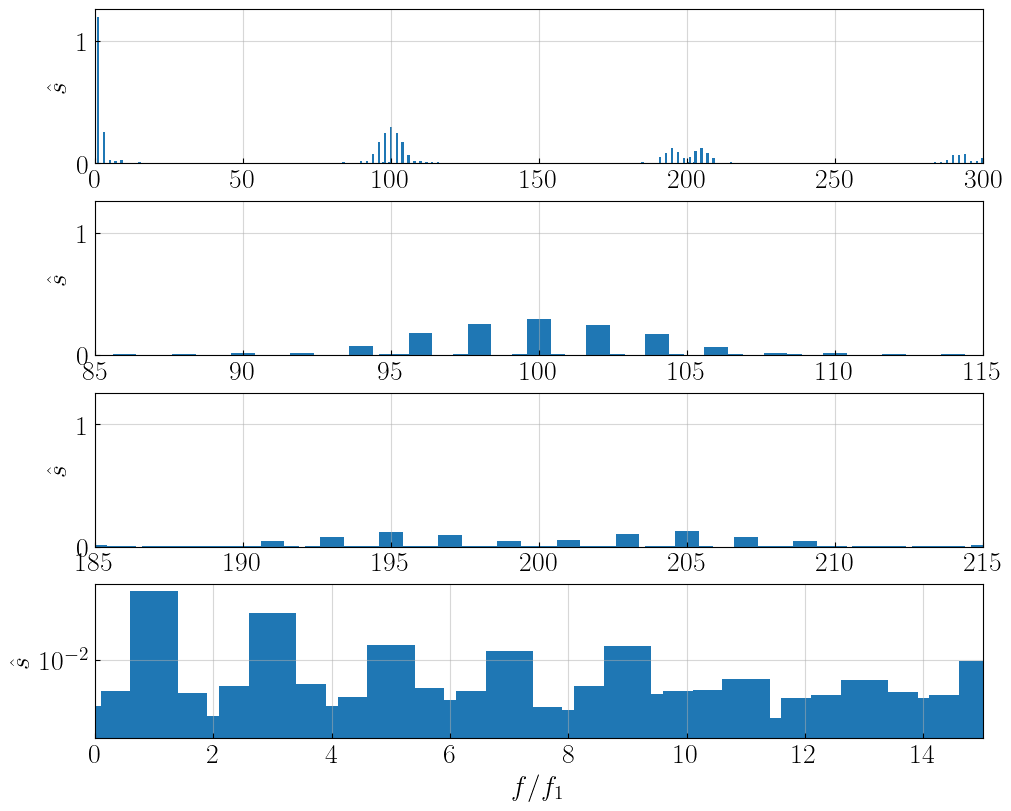

In [19]:
u_ref_t, s_ref_t, s_t, s_0_t = compute_three_phase_signals_zsi_clipping(
    m=1.24,
    u_ref_freq=f_fundamental,
    t=t,
    c_t=c_t,
    u_dc=u_dc
)
fig, axs = three_phase_plot(t, s_ref_t, c_t, s_t, s_0_t)
plt.show()
plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_fundamental)
plt.show()

At maximum modulation index: $m = 4/3$.

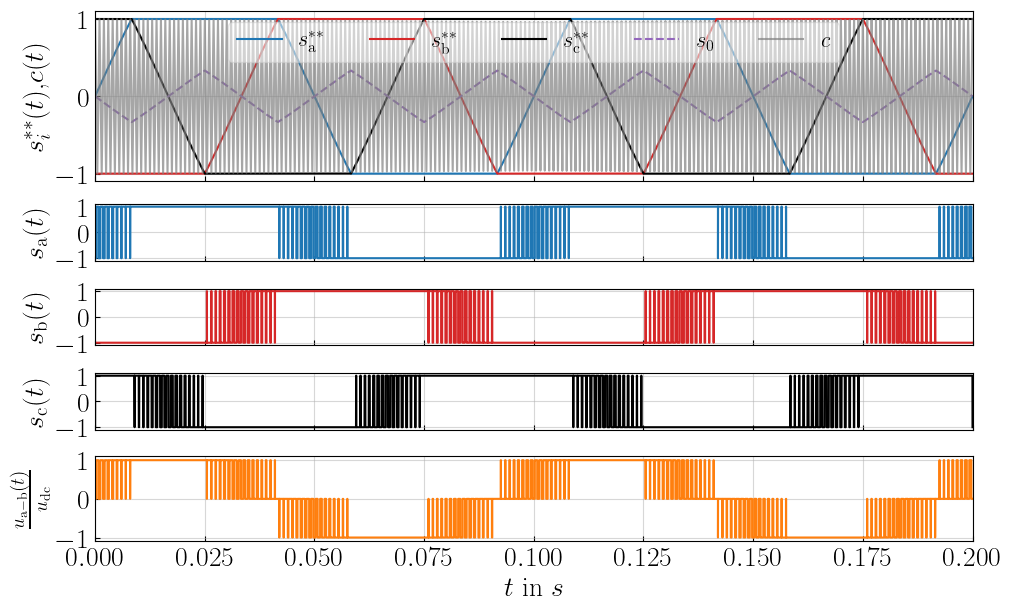

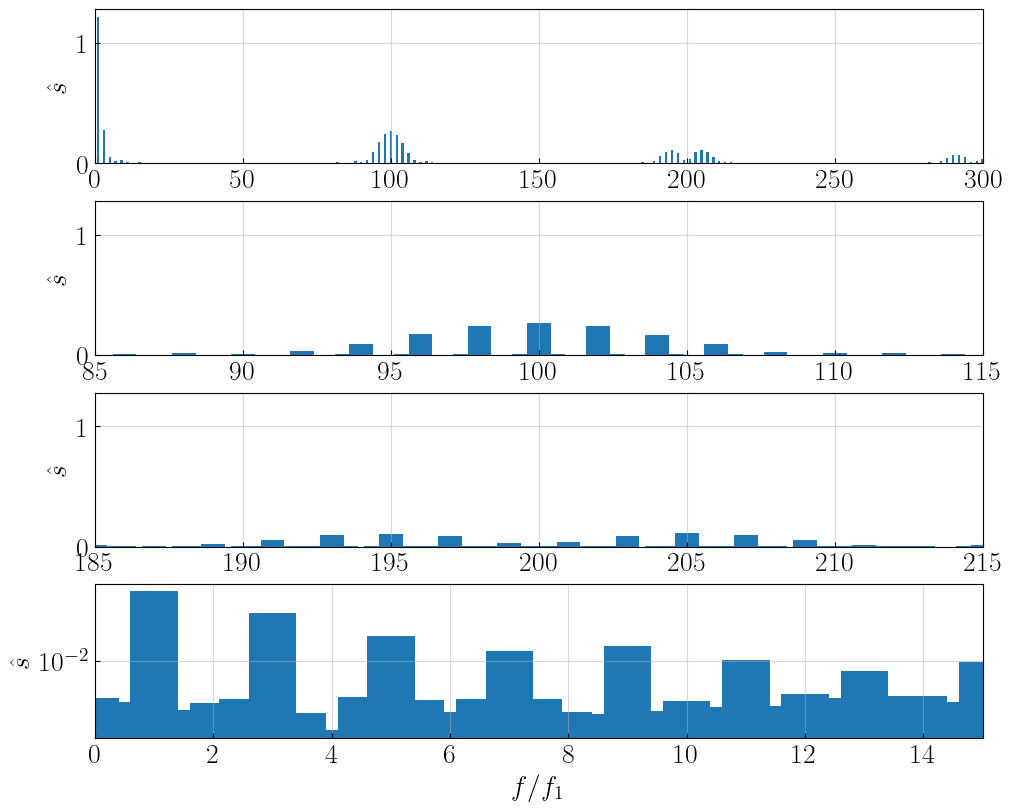

In [20]:
u_ref_t, s_ref_t, s_t, s_0_t = compute_three_phase_signals_zsi_clipping(
    m=4/3,
    u_ref_freq=f_fundamental,
    t=t,
    c_t=c_t,
    u_dc=u_dc
)
fig, axs = three_phase_plot(t, s_ref_t, c_t, s_t, s_0_t)
plt.show()
plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_fundamental)
plt.show()

### 6-step operation:

6-step operation is utilized at the voltage and current limit (generally for maximum speed operation).
Note that for this operation, no PWM is necessary: The switches are operated open-loop solely based on the momentary electrical angle of the machine.

In practice, the electrical angular velcoity is based on the closed loop process, where the motor interacts with the mechanical load to produce the rotation.
Here, we assume a constant electrical angular frequency for simplicity.

In [21]:
f_el = 25  # Hz
omega_el = 2 * jnp.pi * f_el

In [22]:
eps_el = (omega_el * t) % (2 * jnp.pi)

sector = (eps_el / (jnp.pi / 3)).astype(int) % 6

switching_table = jnp.array([
    [ 1, -1, -1],
    [ 1,  1, -1],
    [-1,  1, -1],
    [-1,  1,  1],
    [-1, -1,  1],
    [ 1, -1,  1],
])

s_t = switching_table[sector]

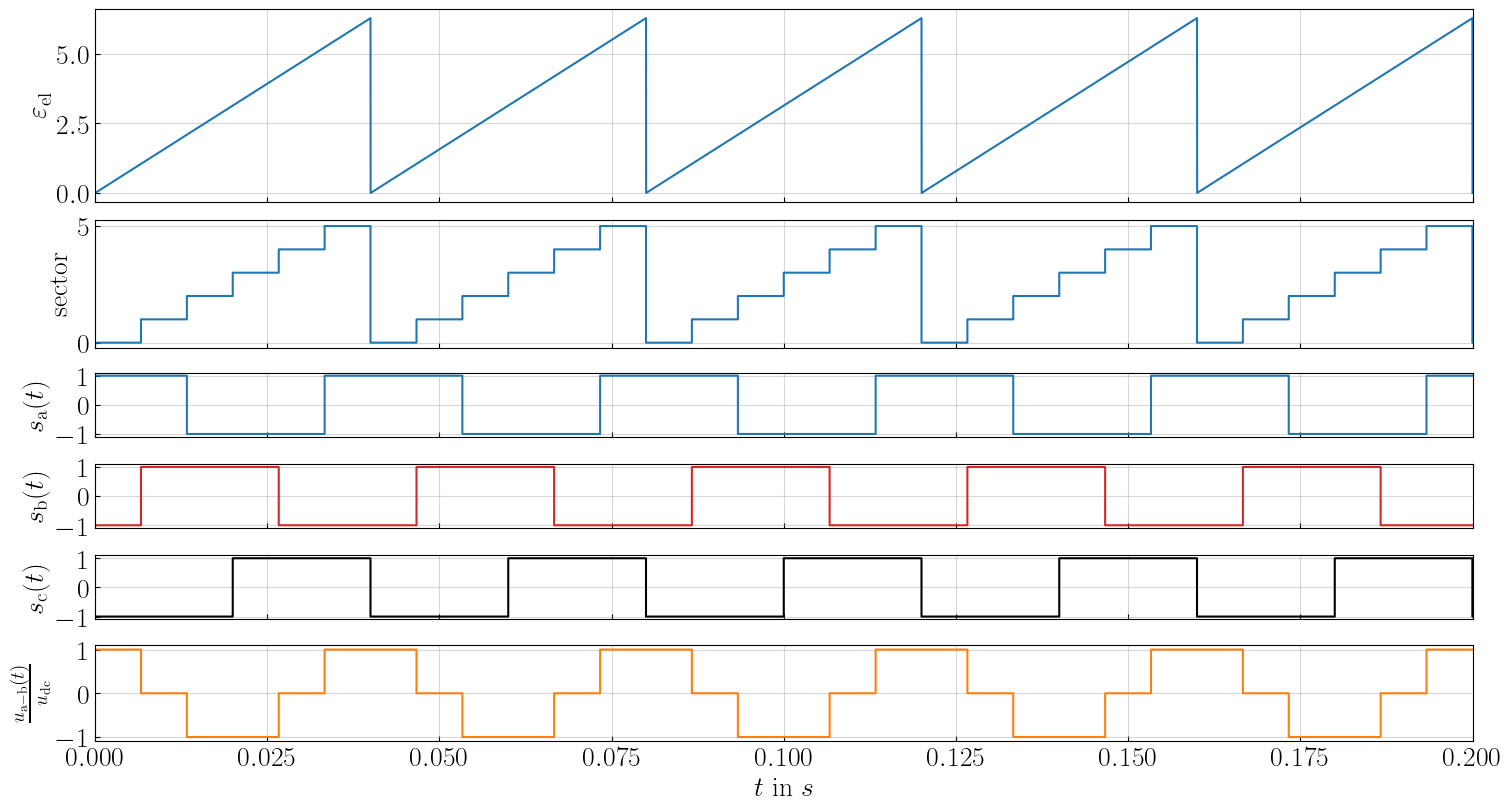

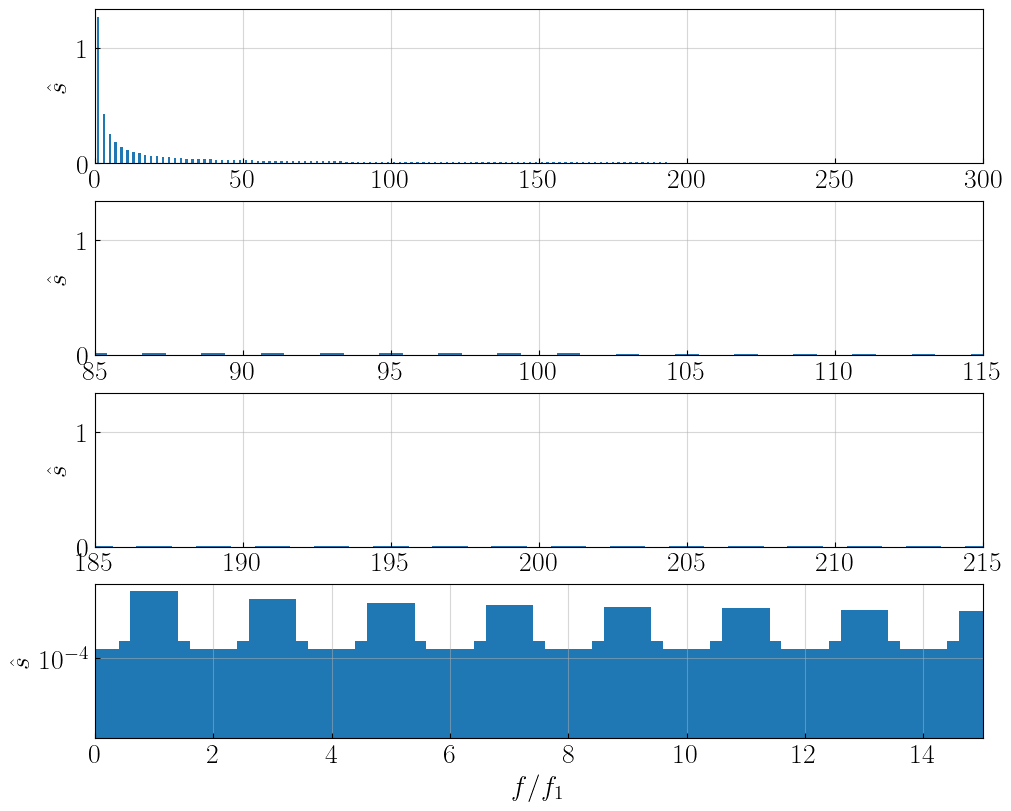

In [23]:
fig_left, axs = plt.subplots(
    6, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 2, 1, 1, 1, 1.5]}, constrained_layout=True
)
axs[0].plot(t, eps_el, color="tab:blue")


axs[1].step(t, sector, color="tab:blue")
axs[2].step(t, s_t[..., 0], color="tab:blue")
axs[3].step(t, s_t[..., 1], color="tab:red")
axs[4].step(t, s_t[..., 2], color="black")
axs[5].step(t, (s_t[..., 0] - s_t[..., 1]) / 2, color="tab:orange")


for ax in axs:
    ax.grid(alpha=0.5)
    ax.tick_params(which="major", axis="y", direction="in")
    ax.tick_params(which="both", axis="x", direction="in")
    ax.set_xlim(t[0], t[-1])


for ax in axs[2:]:
    ax.set_ylim(-1.1, 1.1)

axs[0].set_ylabel("$\\varepsilon_{\\mathrm{el}}$")
axs[1].set_ylabel("sector")
axs[2].set_ylabel("$s_\\mathrm{a}(t)$")
axs[3].set_ylabel("$s_\\mathrm{b}(t)$")
axs[4].set_ylabel("$s_\\mathrm{c}(t)$")
axs[5].set_ylabel("$\\frac{u_\\mathrm{a-b}(t)}{u_\\mathrm{dc}}$")
axs[-1].set_xlabel("$t$ in $s$")

plt.show()

plot_fft_spectrum(s_t[..., 0], f_sampling, N, f_el)
plt.show()

In [24]:
get_effective_value(s_t[..., 0] - s_t[..., 1])

Array(1.633034, dtype=float32)

The theoretical THD for the 6-step operation can be analytically computed with the infinite series (see "Pulse Width Modulation for Power Converters: Principles and Practice" by D. Grahame Holmes and Thomas A. Lipo (2003), pp. 64-65):

$$ \mathrm{THD}_\mathrm{6-step, 1phase} = \sqrt{\sum^\infty_{n=3,5,7,9,11,13,15,17,\dots} \frac{1}{n^2}} \approx 0.4834$$

$$ \mathrm{THD}_\mathrm{6-step, l2l} = \sqrt{\sum^\infty_{n=5,7,11,13,17,\dots} \frac{1}{n^2}} \approx 0.3108$$

In [25]:
# single phase
amps, freqs = get_fft_spectrum(s_t[..., 0], f_sampling, N)
compute_THD(amps, freqs, f_el)

Array(0.48342794, dtype=float32)

In [26]:
# line to line
amps, freqs = get_fft_spectrum(s_t[..., 0] - s_t[..., 1], f_sampling, N)
compute_THD(amps, freqs, f_el)

Array(0.31082514, dtype=float32)

### Interactive plot PWM:

In [27]:
%matplotlib widget

In [28]:
from helper_functions import InteractivePWMVisualizer

In [29]:
# setup parameters and carrier signal

T_full = 0.2 # s
N = 10_000
f_sampling = N / T_full  # 'N' samples per 'T_full' seconds

f_p = 1000  # Hz
T_p = 1 / f_p
t = jnp.linspace(0, T_full, N)

u_dc = 20  # V
print(t.shape)

(10000,)


There are two unsolved issues for this visualization:
- If the full left half of the plot is not showing up, rerun the cell.
- If some part of the plot is not showing, slightly resizing the window for the left plot usually fixes the issue.

In [31]:
plt.close('all')
plt.ioff()

visualizer = InteractivePWMVisualizer(
    t,
    c_t,
    u_dc,
    f_p,
    compute_three_phase_signals=jax.jit(compute_three_phase_signals),
    compute_three_phase_signals_zsi_minmax=jax.jit(compute_three_phase_signals_zsi_minmax),
    compute_three_phase_signals_zsi_clipping=jax.jit(compute_three_phase_signals_zsi_clipping),
)

display(visualizer.ui, visualizer.out)

Output(outputs=({'name': 'stdout', 'text': 'l2l THD:            1.04698\nl2l eff. value:     1.24370\n', 'outp…